In [10]:
import torch

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from itertools import cycle
from functools import partial
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from src.io import load_data
from src.feature import variance_feature, annotate_labels, our_feature
from src.learning import random_fit_and_eval, RMSE, MAPE
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nankurtosis,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar
)

plt.rcParams['font.size'] = 14
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# data_folder = Path.cwd().parent / 'data/raw'
data_folder = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
data = load_data(data_folder, interp_dims=50)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells: 100%|██████████| 151/151 [12:41<00:00,  5.04s/it] 


In [12]:
# dir_path = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
# import os
# for i in os.listdir(dir_path):
#     print(i)
#     raw_path = os.path.join(dir_path, i)
#     with open(raw_path, 'rb') as f:
#         cell_data = pickle.load(f)
#         print(len(cell_data[1]['t_c']), len(cell_data[1]['t_d']))
        

In [13]:
scores = {}
seeds = list(range(16))  # Randomness for dataset split and model initialization
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
num_early_cycles = 50

smoother = partial(savgol_smooth, window=51, order=3)


In [14]:

y_relative = np.array([
    label for _, label in relative_labels.items() if label > num_early_cycles
])

X_relative = torch.stack([
    torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in data[cell][:50]
    ]) for cell, label in relative_labels.items() if label > num_early_cycles
]).permute(0, 2, 1, 3).contiguous()


In [15]:
X_qdlinear = np.stack([
    np.stack([
        cycle_data['Q_d(V_d)'][-1]
        for cycle_data in data[cell][:50]
    ]) 
    for cell, label in relative_labels.items() if label > num_early_cycles
])
X_qdlinear.shape

(95, 50, 100)

In [16]:
def print_score(model_score):
    mean_score = np.mean(model_score, axis=0).squeeze(), np.std(model_score, axis=0).squeeze()
    train_RMSE, test_RMSE, train_RMSE_variance, test_RMSE_variance =  mean_score[0][0][0], mean_score[0][0][1], mean_score[1][0][0], mean_score[1][0][1]
    train_MAPE, test_MAPE, train_MAPE_variance, test_MAPE_variance  =  mean_score[0][1][0], mean_score[0][1][1], mean_score[1][1][0], mean_score[1][1][1]
    print(f'train_RMSE:{train_RMSE:.2f} ± {train_RMSE_variance:.0f}, test_RMSE:{test_RMSE:.2f} ± {test_RMSE_variance:.0f}' )
    print(f'train_MAPE:{train_MAPE:.2f} ± {train_MAPE_variance:.0f}, test_MAPE:{test_MAPE:.2f} ± {test_MAPE_variance:.0f}' )

# Our model

In [17]:
predictions = {}
# interpolate dim = 100
from src.feature import our_feature
X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
     for cell, label in relative_labels.items() if label > num_early_cycles]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)

import json
with open('./data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
# data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X_temp = np.array([int(date_tag2temp[cell].split('C')[0]) for cell, label in relative_labels.items() if label > num_early_cycles])
X_temp = X_temp.reshape(X_temp.shape[0], -1)

task_type = 'relative'

X, y = eval(f'X_{task_type}'), eval(f'y_{task_type}')
key = 'Ours'
X_ours, fea_names = our_feature(
    X,
    num_cycle_groups=7,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name= True,
    device='cuda:0'
)
X_ours = np.concatenate([X_ours, intercept], axis=1)
fea_names.extend(['Qd_intercept_k','Qd_intercept_b','Qc_intercept_k','Qc_intercept_b'])
print(X_ours.shape, len(fea_names))
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)


scores[key] = []
predictions[key] = []
feature_importances = []
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, test_y, test_pred = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True
    )
    # score, feature_importance= random_fit_and_eval(
    #     X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, feature_name= fea_names, return_train_loss=True
    # )
    scores[key].append(score)
    predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

(95, 112900) 112900


Processing Ours:   0%|          | 0/16 [00:00<?, ?it/s]

Processing Ours: 100%|██████████| 16/16 [48:19<00:00, 181.20s/it]

model: Ours
train_RMSE:65.42 ± 6, test_RMSE:144.88 ± 27
train_MAPE:9.67 ± 1, test_MAPE:28.12 ± 4


In [ ]:
# # 50
# train_RMSE:65.42 ± 6, test_RMSE:144.88 ± 27
# train_MAPE:9.67 ± 1, test_MAPE:28.12 ± 4

# #100
# train_RMSE:65.21 ± 5, test_RMSE:142.42 ± 27
# train_MAPE:9.57 ± 1, test_MAPE:27.55 ± 4

# # 200
# train_RMSE:64.88 ± 6, test_RMSE:141.30 ± 27
# train_MAPE:9.52 ± 1, test_MAPE:27.31 ± 4
# # 500
# train_RMSE:63.94 ± 6, test_RMSE:139.19 ± 26
# train_MAPE:9.57 ± 1, test_MAPE:27.57 ± 4
# # 1000
# train_RMSE:63.96 ± 6, test_RMSE:137.67 ± 27
# train_MAPE:9.22 ± 1, test_MAPE:26.87 ± 4

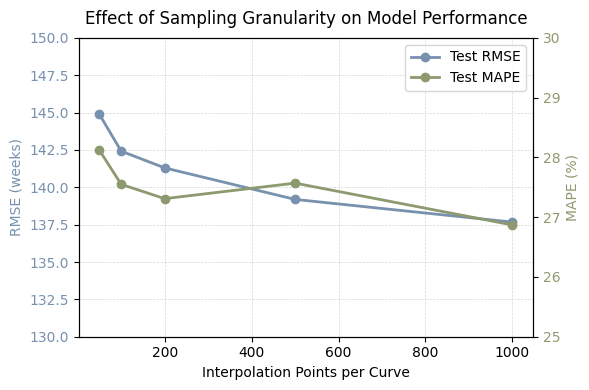

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 数据
points = np.array([50, 100, 200, 500, 1000])
train_rmse = np.array([65.42, 65.21, 64.88, 63.94, 63.96])
test_rmse  = np.array([144.88, 142.42, 141.30, 139.19, 137.67])
train_mape = np.array([9.67, 9.57, 9.52, 9.57, 9.22])
test_mape  = np.array([28.12, 27.55, 27.31, 27.57, 26.87])


# 调色
color_rmse = (119/255, 145/255, 174/255)
color_mape = (141/255, 153/255, 111/255)

fig, ax1 = plt.subplots(figsize=(6, 4))

# 左轴：RMSE
ax1.plot(points, test_rmse, 'o-', color=color_rmse, label='Test RMSE', linewidth=2)
# ax1.plot(points, train_rmse, 's--', color=color_rmse, alpha=0.7, label='Train RMSE', linewidth=1.5)
ax1.set_xlabel('Interpolation Points per Curve')
ax1.set_ylabel('RMSE (weeks)', color=color_rmse)
ax1.tick_params(axis='y', labelcolor=color_rmse)
ax1.set_ylim(130, 150)

# 右轴：MAPE（缩放比例）
ax2 = ax1.twinx()
ax2.plot(points, test_mape, 'o-', color=color_mape, label='Test MAPE', linewidth=2)
# ax2.plot(points, train_mape, 's--', color=color_mape, alpha=0.7, label='Train MAPE', linewidth=1.5)
ax2.set_ylabel('MAPE (%)', color=color_mape)
ax2.tick_params(axis='y', labelcolor=color_mape)
ax2.set_ylim(25, 30)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.set_title('Effect of Sampling Granularity on Model Performance', pad=10)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('./output/ourmodel_performance_vs_interpolation_points.png', dpi=300)
plt.show()


In [ ]:
# interpolate dim = 1000
from src.feature import our_feature
X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
     for cell, label in relative_labels.items() if label > num_early_cycles]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)

import json
with open('./data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
# data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X_temp = np.array([int(date_tag2temp[cell].split('C')[0]) for cell, label in relative_labels.items() if label > num_early_cycles])
X_temp = X_temp.reshape(X_temp.shape[0], -1)

task_type = 'relative'

X, y = eval(f'X_{task_type}'), eval(f'y_{task_type}')
key = 'Ours'
X_ours, fea_names = our_feature(
    X,
    num_cycle_groups=7,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name= True,
    device='cuda:0'
)
X_ours = np.concatenate([X_ours, intercept], axis=1)
fea_names.extend(['Qd_intercept_k','Qd_intercept_b','Qc_intercept_k','Qc_intercept_b'])
print(X_ours.shape, len(fea_names))
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)


scores[key] = []
predictions[key] = []
feature_importances = []
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, test_y, test_pred = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True
    )
    # score, feature_importance= random_fit_and_eval(
    #     X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, feature_name= fea_names, return_train_loss=True
    # )
    scores[key].append(score)
    predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

0: torch.Size([95, 14, 7, 8, 4, 250])
1: torch.Size([95, 84, 7, 4, 250])
2: torch.Size([95, 84, 28, 4, 250])
3: torch.Size([95, 504, 28, 4])
(95, 112900) 112900


Processing Ours: 100%|██████████| 16/16 [47:27<00:00, 177.96s/it]

model: Ours
train_RMSE:63.96 ± 6, test_RMSE:137.67 ± 27
train_MAPE:9.22 ± 1, test_MAPE:26.87 ± 4


In [30]:
# import pickle
# with open('../output/rul_baseline_scores_with_trainloss.pkl', 'wb') as f:
#     pickle.dump(scores, f)

In [76]:
import pickle
with open('../output/rul_baseline_scores.pkl', 'wb') as f:
    pickle.dump(scores, f)

In [77]:
import pickle
with open('../output/rul_baseline_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

In [ ]:
# # save feature importance(figure 3c data)
# import pandas as pd
# fea_imp_data = []
# for seed in range(16):
#     for item in range(20):
#         # print(feature_importances[seed][0][item])
#         fea_imp_data.append([seed, feature_importances[seed][0][item][0], feature_importances[seed][0][item][1]])

# fea_imp = pd.DataFrame(fea_imp_data, columns= ['seed', 'feature_name', 'score'])
# fea_imp.to_csv('../output/feature_importance_rul_v2_cycle7.csv')


In [61]:
# save rul result to csv
table = []
columns = ['model','Train RMSE mean', 'Train RMSE var', 'Test RMSE mean', 'Test RMSE var','Train MAPE mean', 'Train MAPE var', 'Test MAPE mean', 'Test MAPE var']
for key in scores.keys():
    mean = np.mean(scores[key], axis=0).squeeze()
    std = np.std(scores[key], axis=0).squeeze()

    table.append([key, mean[0][0], std[0][0], mean[0][1], std[0][1], mean[1][0], std[1][0], mean[1][1], std[1][1]])
import pandas as pd
result_df = pd.DataFrame(data=table, columns=columns)
result_df["Train RMSE"] = result_df.apply(lambda x: f'{x["Train RMSE mean"]:.2f} ± {x["Train RMSE var"]:.0f}', axis=1)
result_df["Test RMSE"] = result_df.apply(lambda x: f'{x["Test RMSE mean"]:.2f} ± {x["Test RMSE var"]:.0f}', axis=1)

result_df["Train MAPE"] = result_df.apply(lambda x: f'{x["Train MAPE mean"]:.2f} ± {x["Train MAPE var"]:.0f}', axis=1)
result_df["Test MAPE"] = result_df.apply(lambda x: f'{x["Test MAPE mean"]:.2f} ± {x["Test MAPE var"]:.0f}', axis=1)
result_df.to_csv('../output/rul_result.csv')


In [62]:
result_df

,model,Train RMSE mean,Train RMSE var,Test RMSE mean,Test RMSE var,Train MAPE mean,Train MAPE var,Test MAPE mean,Test MAPE var,Train RMSE,Test RMSE,Train MAPE,Test MAPE
0,dummy,203.134811,12.154343,201.065250,28.887598,67.538099,4.782769,75.335884,14.087980,203.13 ± 12,201.07 ± 29,67.54 ± 5,75.34 ± 14
1,IQR($\Delta Q_{100-10}$),201.651440,12.676576,200.963270,29.391738,67.099646,4.963870,76.121547,14.617702,201.65 ± 13,200.96 ± 29,67.10 ± 5,76.12 ± 15
2,Percentile($\Delta Q_{100-10}$),201.446507,12.686250,200.758371,29.396101,66.975500,5.007179,76.089733,14.667789,201.45 ± 13,200.76 ± 29,66.98 ± 5,76.09 ± 15
3,$\Delta Q_{100-10}(4.000$V),198.083403,12.104242,194.973832,29.750986,60.435122,4.202508,66.418591,11.583464,198.08 ± 12,194.97 ± 30,60.44 ± 4,66.42 ± 12
4,log 10 (var(ΔQ100−10 (V))),201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
5,variance model,201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
6,discharge,194.518024,12.134357,205.540412,28.051679,59.776774,4.365243,77.012919,15.013498,194.52 ± 12,205.54 ± 28,59.78 ± 4,77.01 ± 15
7,full,133.603623,9.657945,156.367022,23.513141,25.462375,1.519148,32.428540,5.325984,133.60 ± 10,156.37 ± 24,25.46 ± 2,32.43 ± 5
8,Ridge,190.730431,45.470946,232.726216,132.050929,62.923172,15.774443,80.386768,21.345038,190.73 ± 45,232.73 ± 132,62.92 ± 16,80.39 ± 21
9,Elastic net,129.902910,15.030695,169.916577,26.258038,30.845703,3.907817,48.815793,8.734797,129.90 ± 15,169.92 ± 26,30.85 ± 4,48.82 ± 9
